## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import calculate_stats, build_transforms
from src.utils.plotting import visualize_test_samples, plot_training_history, plot_feature_maps
from src.constants import CLASS_MAP

In [3]:
# Load data 

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_SYNTHETIC_DATA_ROOT = os.path.join(project_root, "data/test/synthetic") 
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform)
test_synthetic_dataset = ChessBoardDataset(root_dir=TEST_SYNTHETIC_DATA_ROOT, transform=train_transform)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_synthetic_loader = DataLoader(test_synthetic_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1125 | Test samples: 132
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 5/5 [00:23<00:00,  4.61s/it]



Calculated training mean: [0.5404442548751831, 0.5397380590438843, 0.538094162940979]
Calculated training std:  [0.10286931693553925, 0.10347479581832886, 0.10441185534000397]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 1/1 [00:05<00:00,  5.64s/it]


Calculated test mean: [0.6565678715705872, 0.6223732829093933, 0.5438754558563232]
Calculated test std:  [0.13988812267780304, 0.14656242728233337, 0.13416872918605804]



In [4]:
# Define baseline model

def get_baseline_model(num_classes=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [5]:
# Initialize model

model = get_baseline_model().to(device)

print("\nModel Initialized: ResNet18 (Pretrained)")
print(f"Output classes: {model.fc.out_features}")


Model Initialized: ResNet18 (Pretrained)
Output classes: 13


## Training

Training on cuda for 8 epochs...


Training Progress:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/8 | Train: Loss=0.0437 Acc=0.9905  Val: Loss=0.0065 Acc=0.9992   [Saved Best]
Epoch 2/8 | Train: Loss=0.0018 Acc=0.9998  Val: Loss=0.0008 Acc=1.0000   [Saved Best]
Epoch 3/8 | Train: Loss=0.0004 Acc=1.0000  Val: Loss=0.0004 Acc=1.0000  
Epoch 4/8 | Train: Loss=0.0002 Acc=1.0000  Val: Loss=0.0004 Acc=1.0000  
Epoch 5/8 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0003 Acc=1.0000  
Epoch 6/8 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0005 Acc=0.9997  
Epoch 7/8 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0002 Acc=1.0000  
Epoch 8/8 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.0002 Acc=1.0000  

Training complete in 4m 6s
Best Val Acc: 1.0000


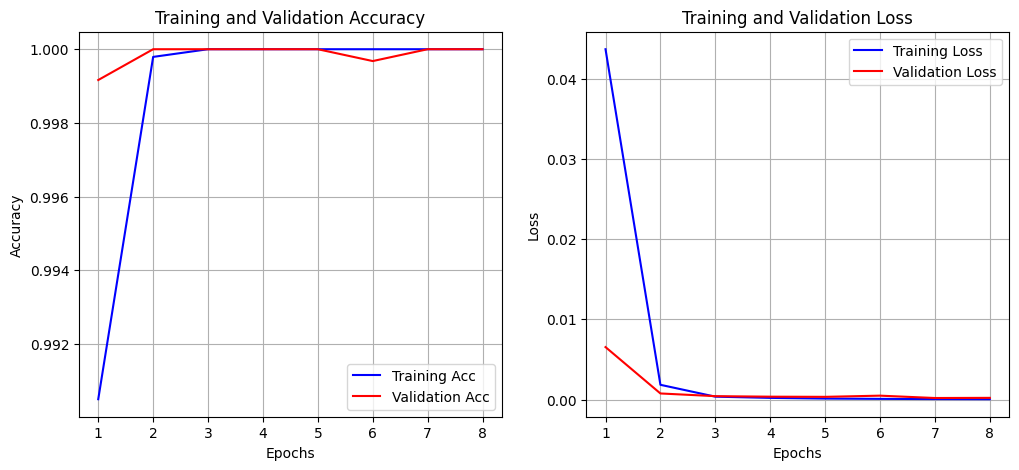

In [6]:
# Training loop

# Configuration
lr = 1e-4
num_epochs = 8
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    num_epochs=num_epochs,
    device=device,
    save_path='baseline_naive_data.pth'
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [7]:
# Evaluation on synthetic test data

square_acc, board_acc = evaluate(best_model, test_synthetic_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 384 boards...


Evaluating:   0%|          | 0/192 [00:00<?, ?it/s]

Square accuracy: 100.00
Board accuracy: 100.00


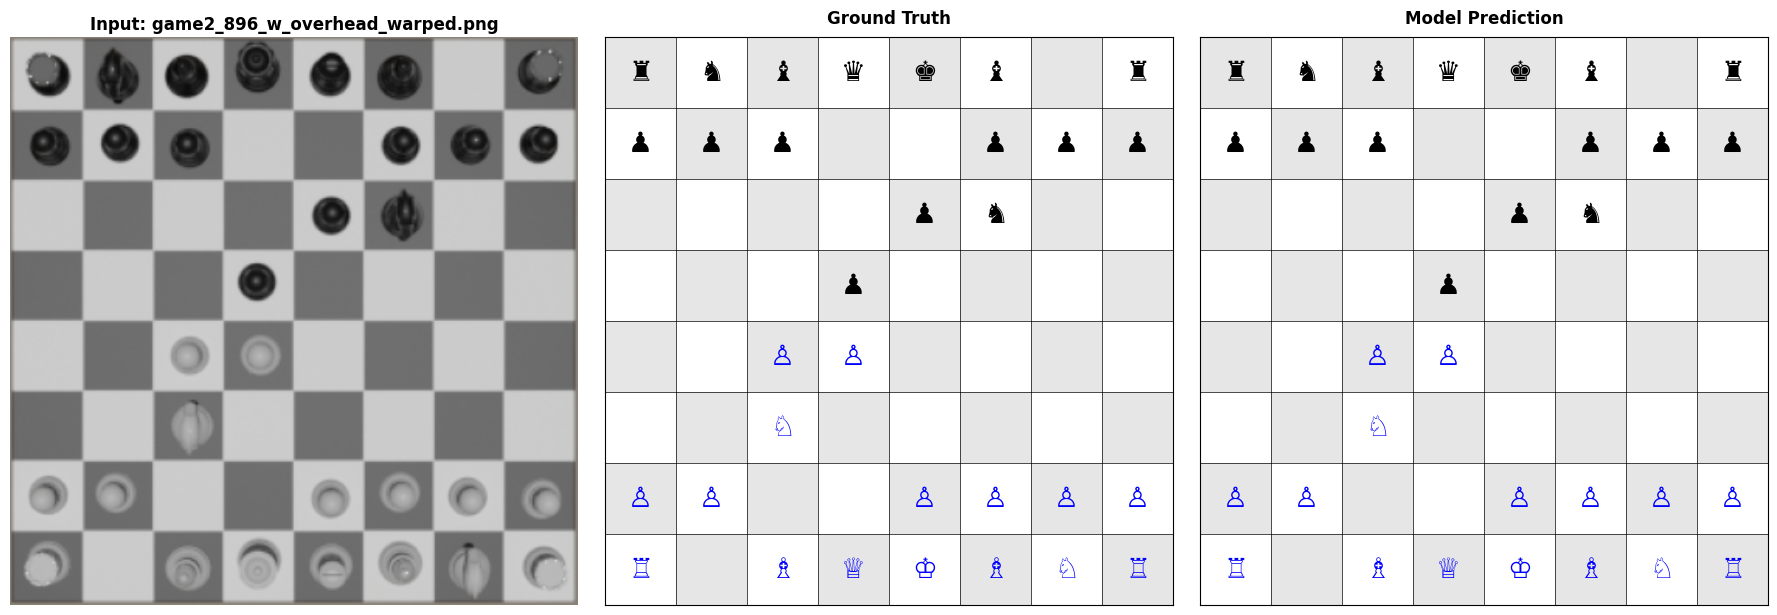

True FEN: rnbqkb1r/ppp2ppp/4pn2/3p4/2PP4/2N5/PP2PPPP/R1BQKBNR
Pred FEN: rnbqkb1r/ppp2ppp/4pn2/3p4/2PP4/2N5/PP2PPPP/R1BQKBNR
PERFECT MATCH


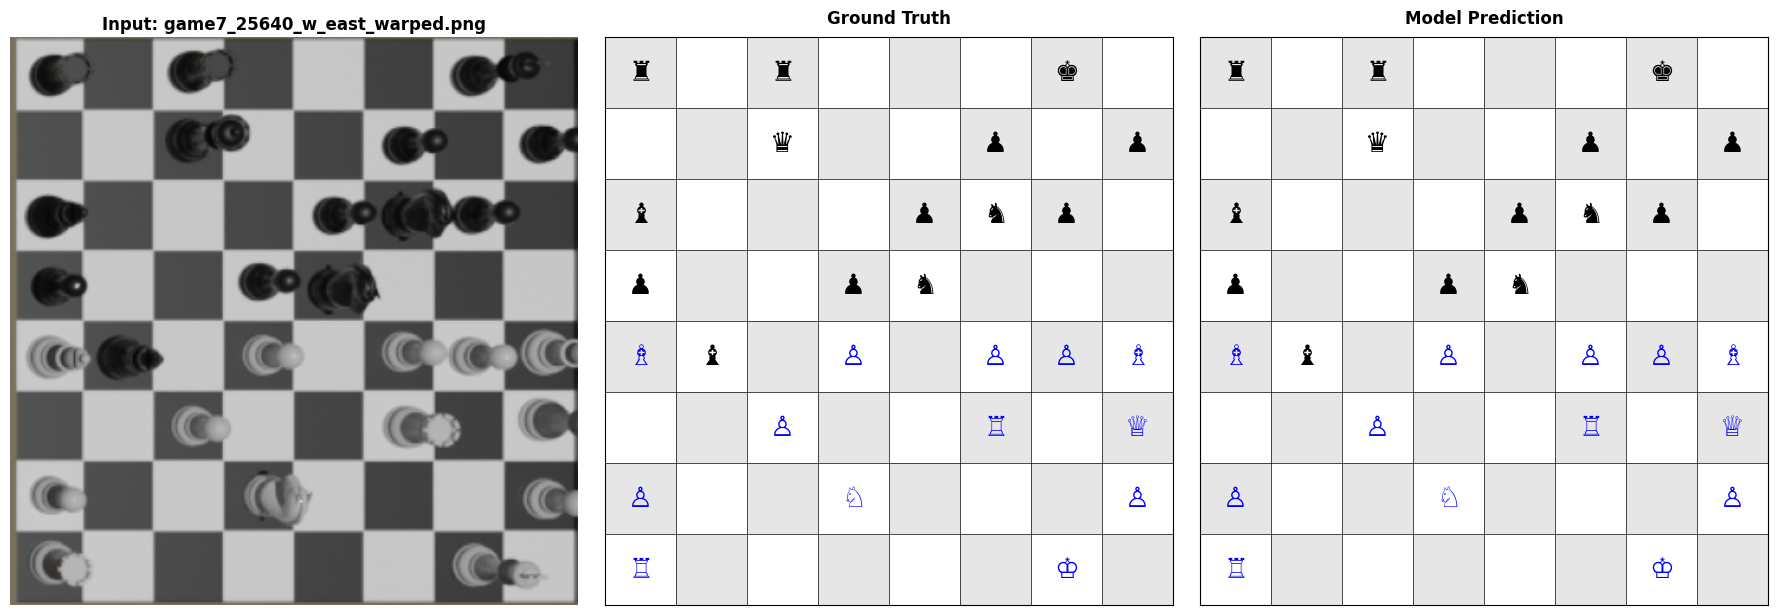

True FEN: r1r3k1/2q2p1p/b3pnp1/p2pn3/Bb1P1PPB/2P2R1Q/P2N3P/R5K1
Pred FEN: r1r3k1/2q2p1p/b3pnp1/p2pn3/Bb1P1PPB/2P2R1Q/P2N3P/R5K1
PERFECT MATCH


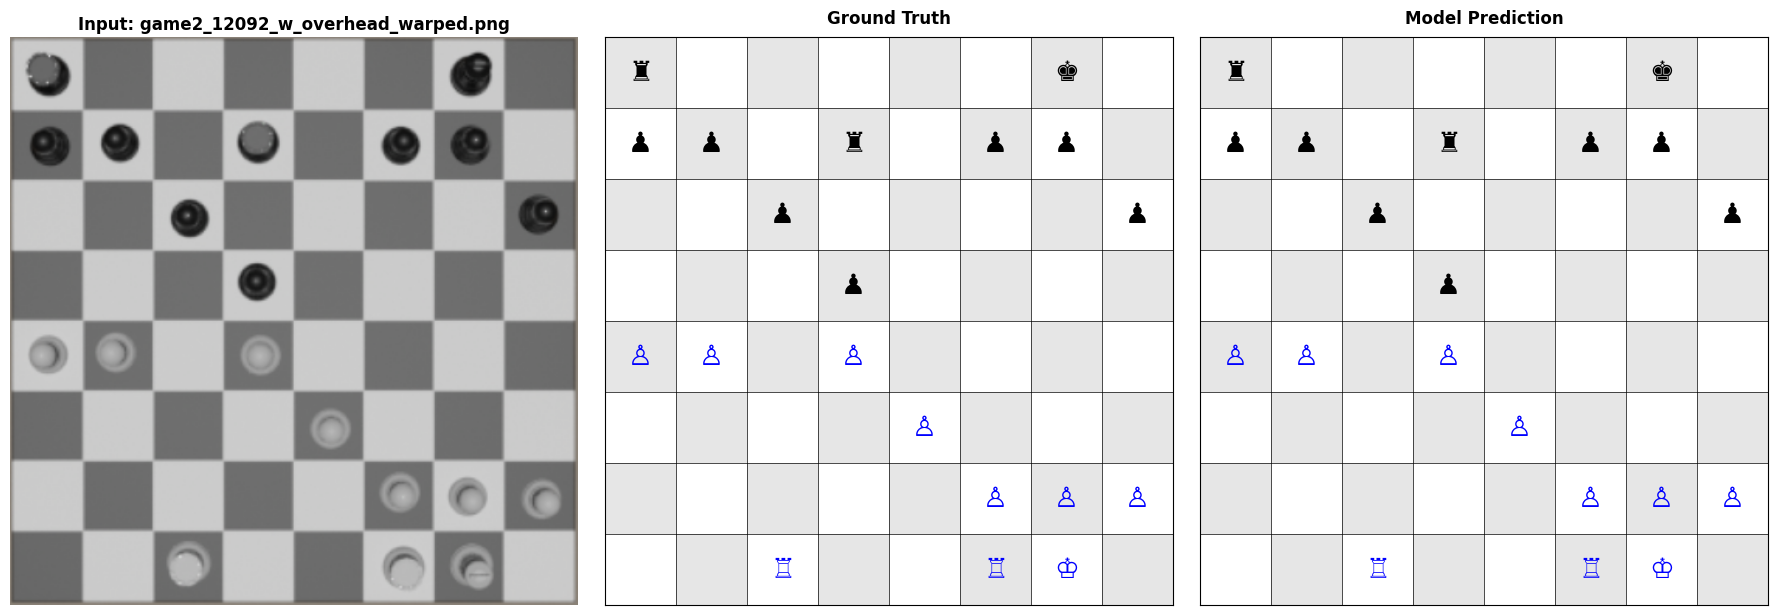

True FEN: r5k1/pp1r1pp1/2p4p/3p4/PP1P4/4P3/5PPP/2R2RK1
Pred FEN: r5k1/pp1r1pp1/2p4p/3p4/PP1P4/4P3/5PPP/2R2RK1
PERFECT MATCH


In [8]:
# Visualizing model outputs

test_synthetic_dataset.return_fen = True
visualize_test_samples(model, test_synthetic_dataset, num_samples=3, device=device)

In [9]:
# Evaluation on real test data

square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 132 boards...


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

Square accuracy: 63.42
Board accuracy: 0.00


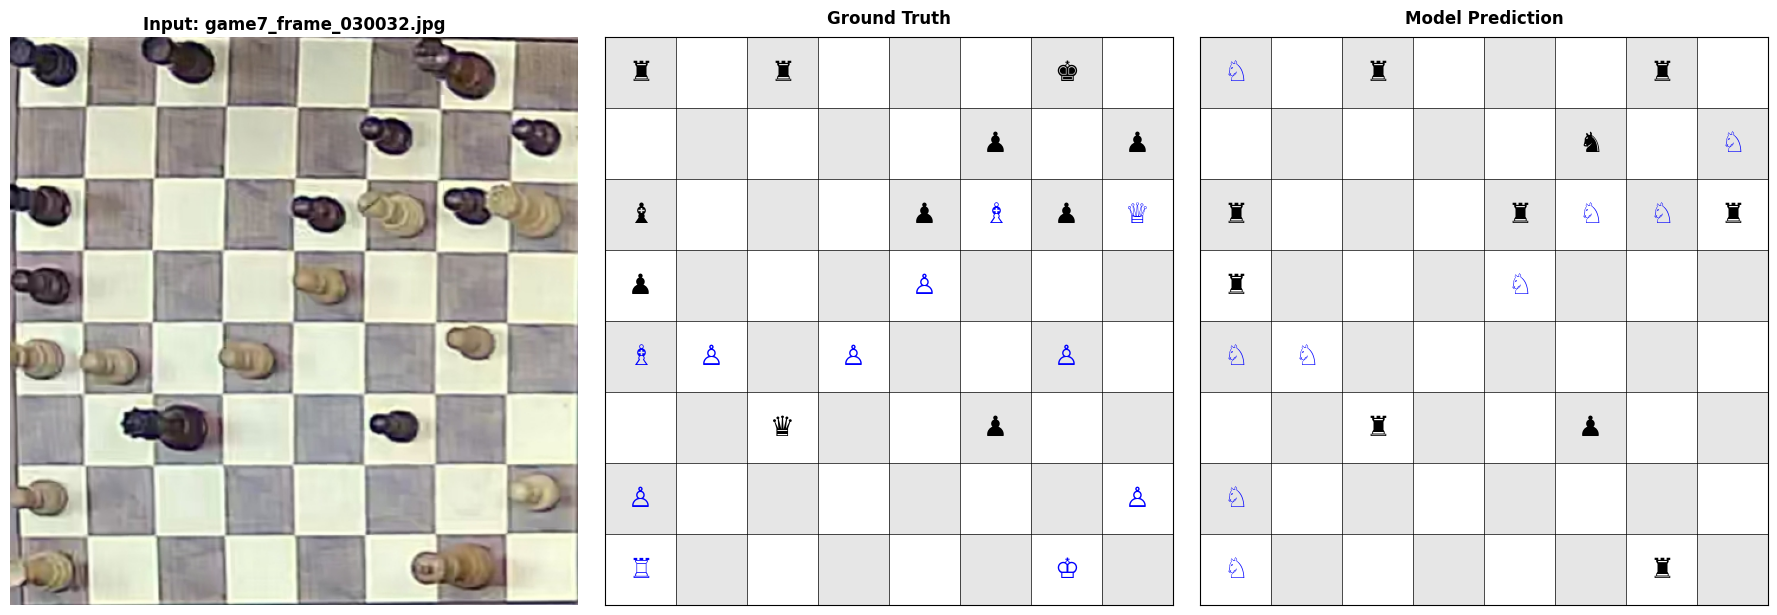

True FEN: r1r3k1/5p1p/b3pBpQ/p3P3/BP1P2P1/2q2p2/P6P/R5K1
Pred FEN: N1r3r1/5n1N/r3rNNr/r3N3/NN6/2r2p2/N7/N5r1
MISMATCH



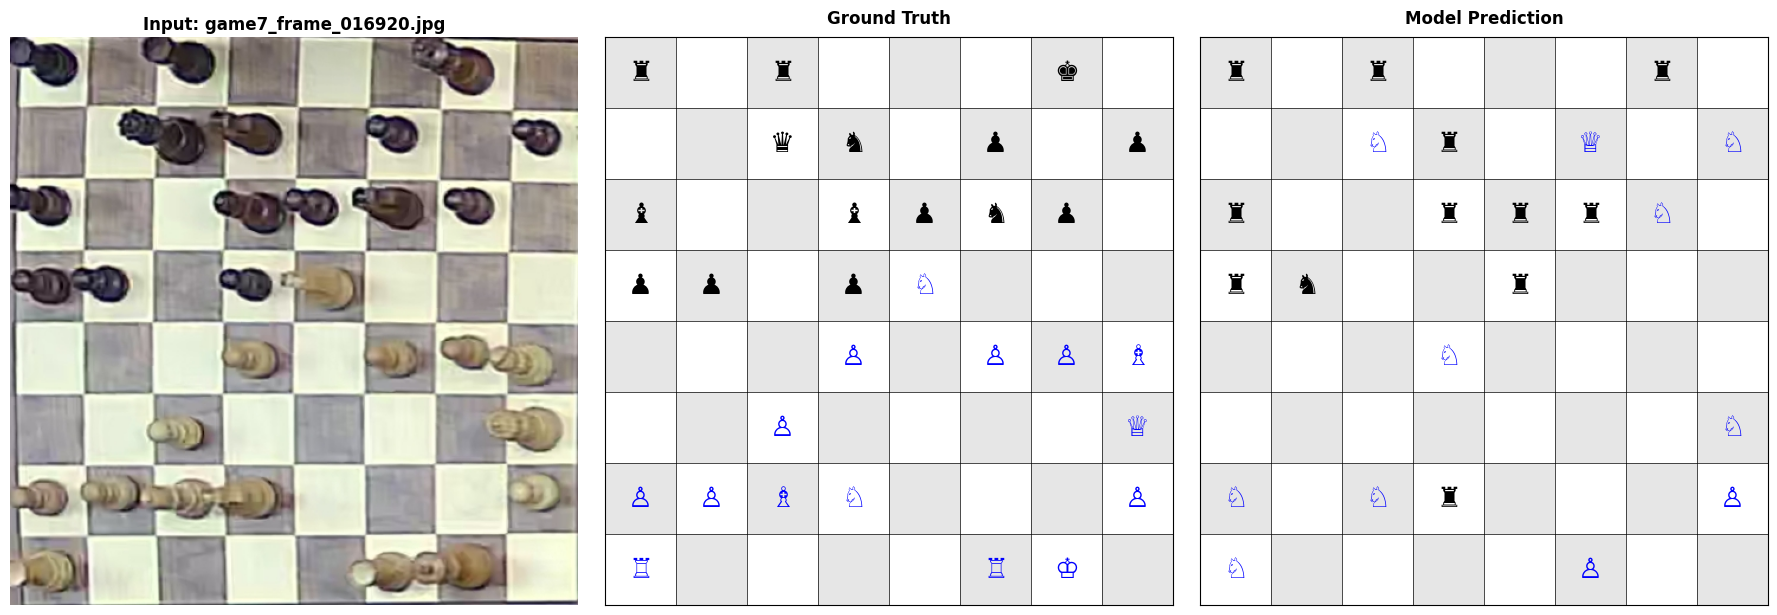

True FEN: r1r3k1/2qn1p1p/b2bpnp1/pp1pN3/3P1PPB/2P4Q/PPBN3P/R4RK1
Pred FEN: r1r3r1/2Nr1Q1N/r2rrrN1/rn2r3/3N4/7N/N1Nr3P/N4P2
MISMATCH



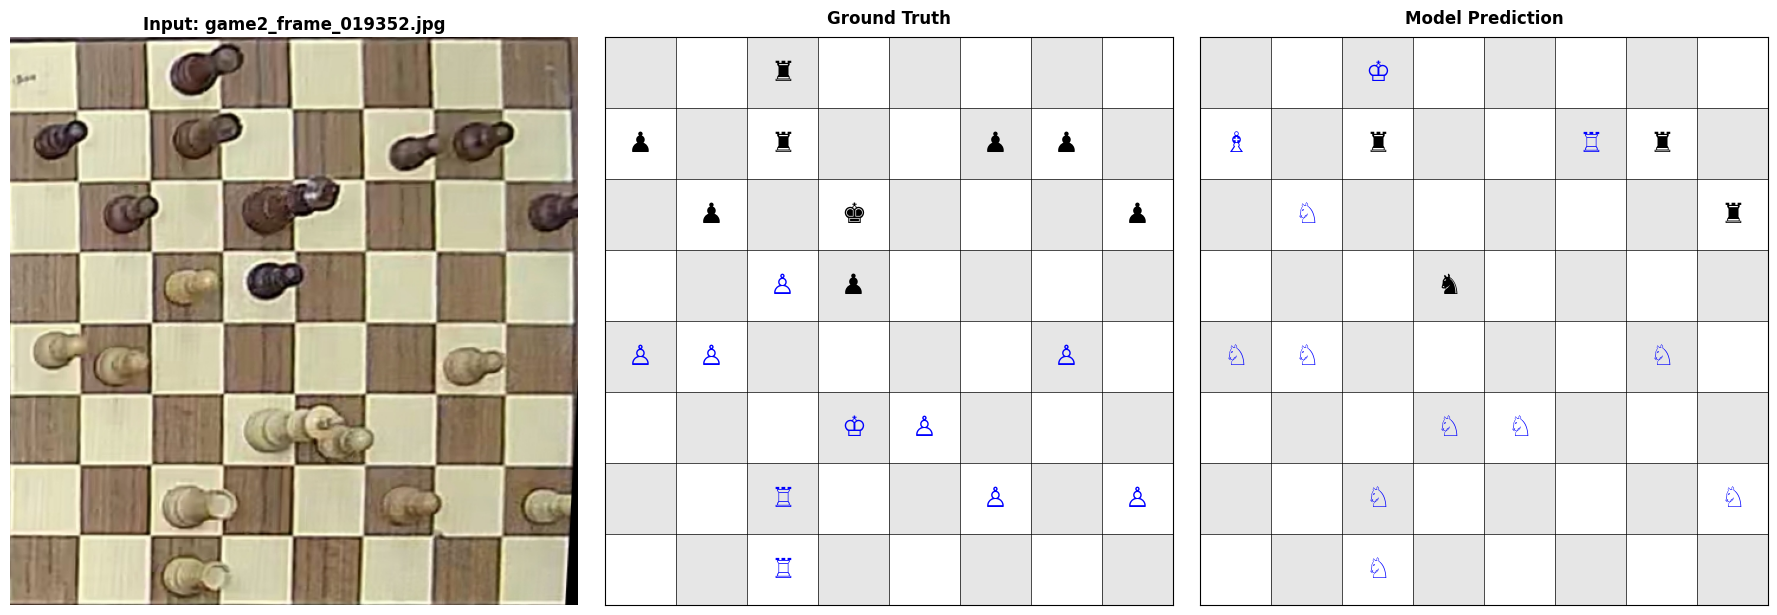

True FEN: 2r5/p1r2pp1/1p1k3p/2Pp4/PP4P1/3KP3/2R2P1P/2R5
Pred FEN: 2K5/B1r2Rr1/1N5r/3n4/NN4N1/3NN3/2N4N/2N5
MISMATCH



In [10]:
# Visualizing model outputs

test_real_dataset.return_fen = True
visualize_test_samples(model, test_real_dataset, num_samples=3, device=device)

Accuracy per Class:

white_pawn: 2.95% (27/914 correct)
white_rook: 3.26% (7/215 correct)
white_knight: 18.31% (26/142 correct)
white_bishop: 0.00% (0/164 correct)
white_queen: 0.00% (0/95 correct)
white_king: 0.00% (0/132 correct)
black_pawn: 1.54% (14/908 correct)
black_rook: 70.51% (165/234 correct)
black_knight: 0.00% (0/138 correct)
black_bishop: 0.00% (0/155 correct)
black_queen: 0.00% (0/94 correct)
black_king: 0.00% (0/132 correct)
empty     : 99.88% (5119/5125 correct)




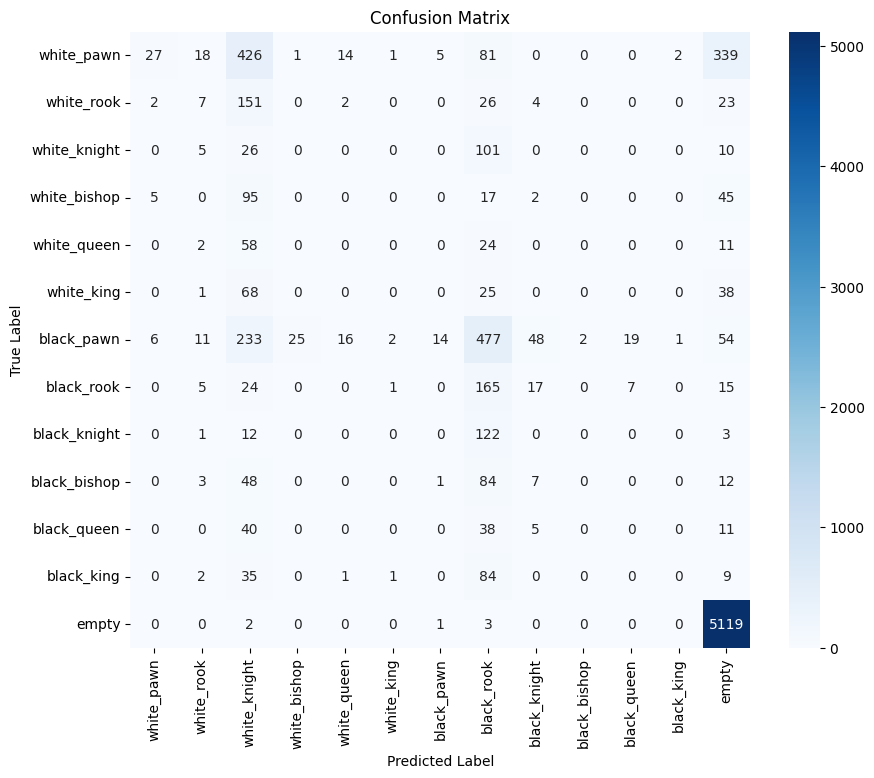

In [11]:
# Analyzing model outputs and performance

class_names = list(CLASS_MAP.keys())
test_real_dataset.return_fen = False
analyze_model_performance(best_model, test_real_loader, class_names, device)

In [12]:
def collect_images(dataset, class_names, classes_to_plot):
    collected_images = []
    labels_for_plot = []
    
    print("Collecting samples...")
    for cls_name in classes_to_plot:
        count = 0
    
        for i in range(len(dataset)):
            if count >= samples_per_class: 
                break
            
            imgs, lbls = dataset[i]
            
            target_idx = class_names.index(cls_name)
            matches = (lbls == target_idx).nonzero(as_tuple=True)[0]
            
            for idx in matches:
                if count >= samples_per_class: 
                    break
                collected_images.append(imgs[idx])
                labels_for_plot.append(cls_name)
                count += 1

    return collected_images, labels_for_plot


test_synthetic_dataset.return_fen = False
classes_to_plot = class_names
samples_per_class = 5 

## Real image feature maps

Extracting features and running PCA...



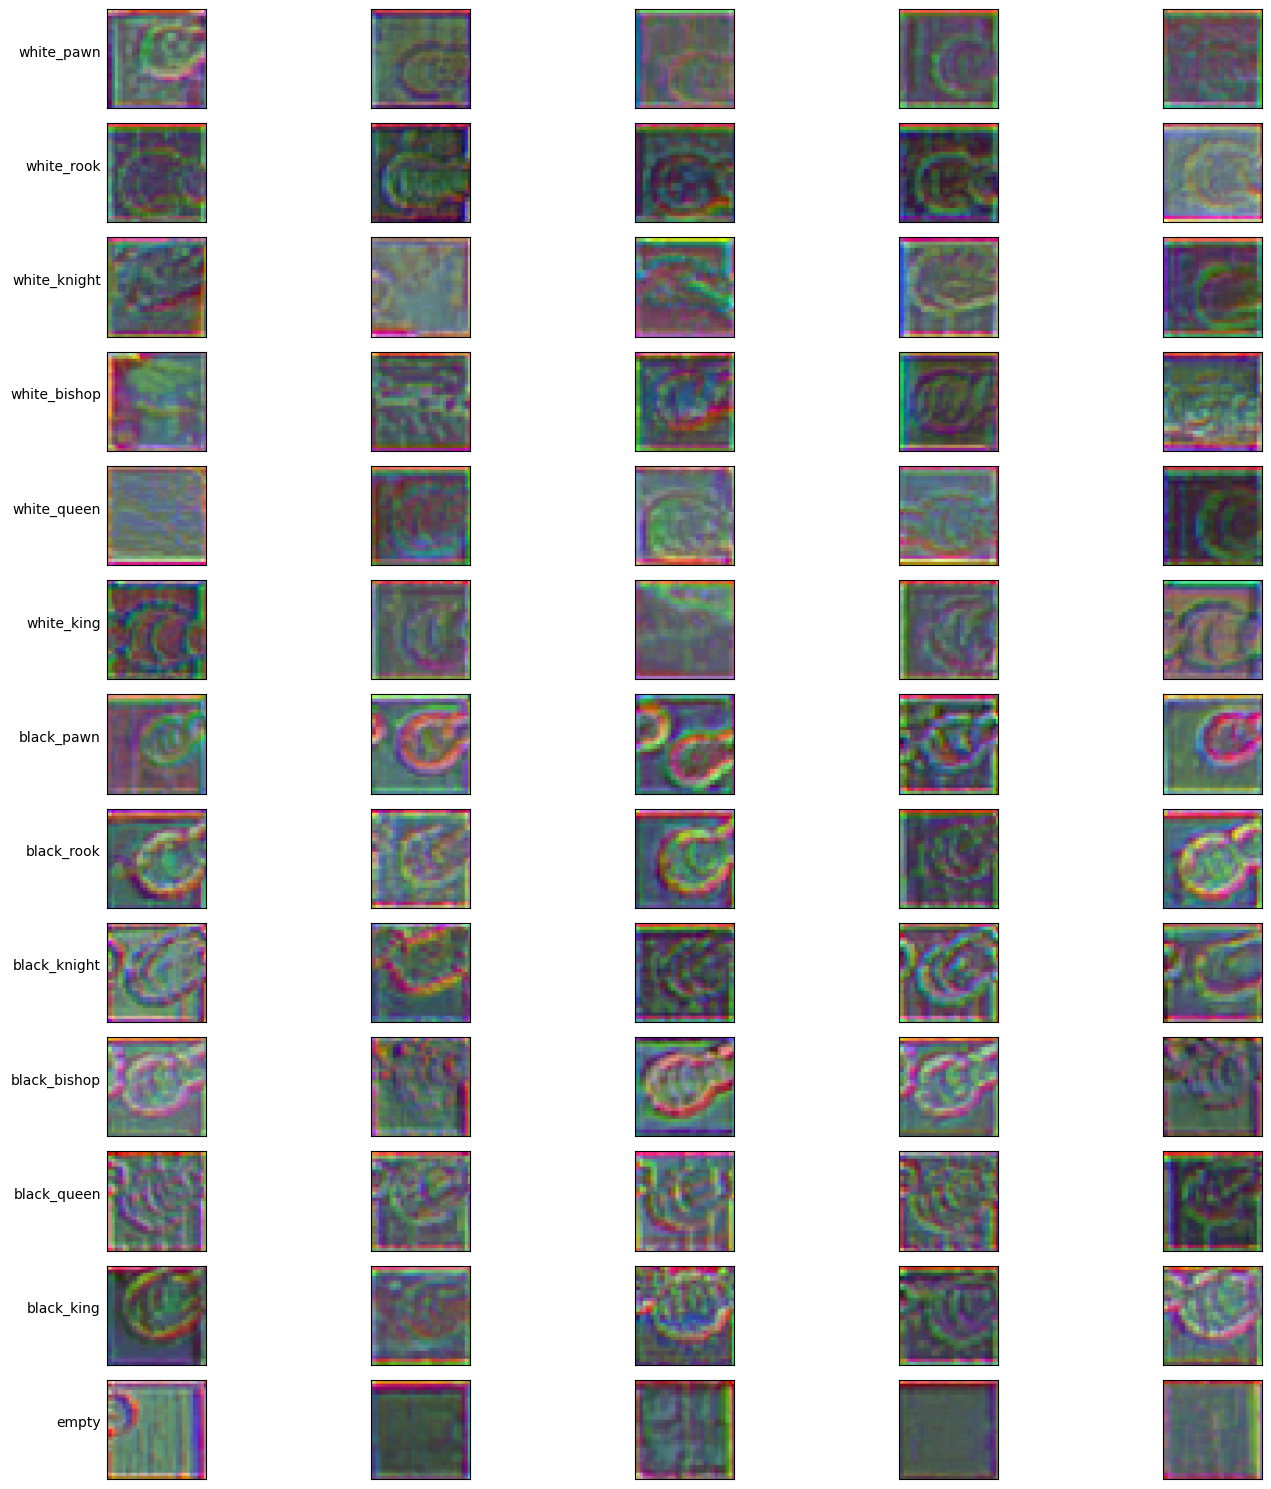

In [13]:
collected_images, labels_for_plot = collect_images(test_real_dataset, class_names, classes_to_plot)
plot_feature_maps(best_model, collected_images, classes_to_plot, labels_for_plot, samples_per_class)

## Synthetic image feature maps

Extracting features and running PCA...



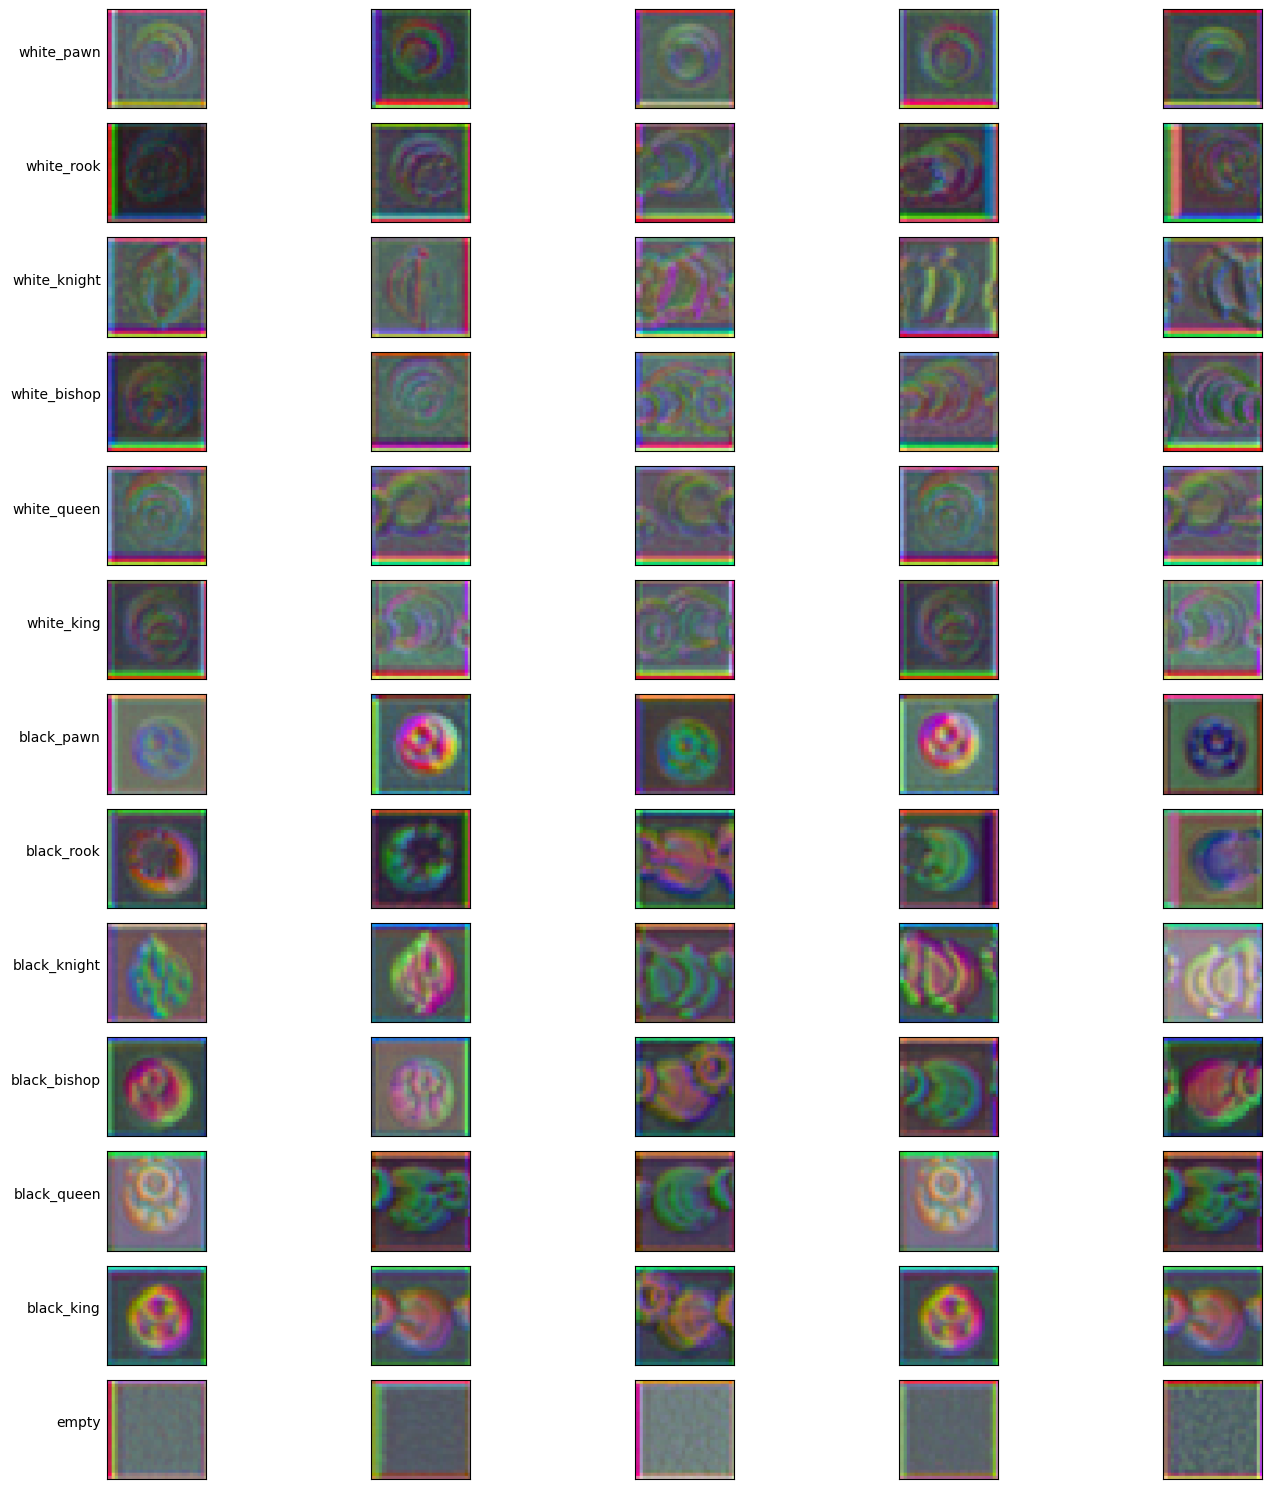

In [14]:
collected_images, labels_for_plot = collect_images(test_synthetic_dataset, class_names, classes_to_plot)
plot_feature_maps(best_model, collected_images, classes_to_plot, labels_for_plot, samples_per_class)